# 09 — ACLED Control Events × Wikipedia Pre-analysis

**Goal**: Compare ACLED **territorial control signal events** (`is_control_signal=True`) with
Wikipedia-derived territorial control labels (ground truth) for Myanmar, on a PRIO-GRID cell × month panel.

Control signal events are the ACLED sub-types that directly imply territorial change:
- *Non-state actor overtakes territory*
- *Non-violent transfer of territory*
- *Government regains territory*
- *Headquarters or base established*

For every cell-month that contains at least one such event, we classify the ACLED-implied
side as `gov` or `opo` via the existing actor taxonomy, then compare with the Wikipedia label.

**Outputs**:
- `reports/figures/09_acled_wiki_agreement_smallmultiples.png` — month-by-month small-multiples map
- `reports/figures/09_acled_wiki_agreement_animated.gif` — animated map over time
- `reports/figures/09_agreement_counts_timeseries.png` — monthly agreement counts time series
- `reports/figures/09_disagreement_cells_map.png` — spatial map of disagreement clusters
- `notebook_training/checkpoints/09_acled_wiki_comparison.parquet` — per-cell-month comparison frame

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, io as _io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import geopandas as gpd
from shapely.geometry import box
from PIL import Image
from pathlib import Path

# ── Paths (relative to notebook_training/) ───────────────────────────────────
NB_DIR = Path('.')
ROOT   = Path('../..')
FIG    = ROOT / 'reports' / 'figures'
CKPT   = Path('../checkpoints')
FIG.mkdir(parents=True, exist_ok=True)
CKPT.mkdir(parents=True, exist_ok=True)

ACLED_PATH = CKPT / 'myanmar_acled_grouped.parquet'
WIKI_PATH  = ROOT / 'data/processed/myanmar_priogrid_labels.csv'
GADM_PATH  = ROOT / 'data/raw/gadm/gadm41_MMR.gpkg'
CKPT_OUT   = CKPT / '09_acled_wiki_comparison.parquet'

# ── Date constants ────────────────────────────────────────────────────────────
COUP_DATE  = pd.Timestamp('2021-02-01')
WIKI_START = pd.Timestamp('2023-11-01')   # first Wikipedia snapshot
WIKI_END   = pd.Timestamp('2026-03-31')   # last Wikipedia snapshot

# ── Myanmar bounding box ──────────────────────────────────────────────────────
MMR = (92.0, 9.5, 101.5, 28.5)   # (lon_min, lat_min, lon_max, lat_max)

# ── Colour scheme (consistent with notebooks 03–08) ──────────────────────────
AGREE_COLORS = {
    'agree':          '#A5D6A7',   # light green
    'disagree':       '#EF5350',   # red
    'wiki_contested': '#C8E6C9',   # pale green (Wiki says contested → partial match)
    'no_info':        '#BDBDBD',   # grey (no Wiki label for this cell-month)
    'acled_mixed':    '#FFB74D',   # orange (control events from both sides in same cell-month)
    'no_acled':       '#F5F5F5',   # near-white (cell had no control signal event this month)
}
AGREE_LABELS = {
    'agree':          'Agree (ACLED = Wiki)',
    'disagree':       'Disagree',
    'wiki_contested': 'Wiki: contested',
    'no_info':        'Wiki: no info',
    'acled_mixed':    'ACLED: mixed sides',
    'no_acled':       'No control event',
}
AGREE_ORDER = ['agree', 'disagree', 'wiki_contested', 'no_info', 'acled_mixed']

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

# ── PRIOGRID geometry helper (identical to step8/step9) ──────────────────────
def gid_to_geometry(gid):
    """Convert a PRIOGRID GID to its 0.5° × 0.5° box geometry."""
    row     = (gid - 1) // 720 + 1
    col     = (gid - 1) % 720 + 1
    lon_min = (col - 1) * 0.5 - 180
    lat_min = (row - 1) * 0.5 - 90
    return box(lon_min, lat_min, lon_min + 0.5, lat_min + 0.5)

print('Setup complete.')

Setup complete.


## 1. Load ACLED data — control signal events only

We load the checkpoint (`myanmar_acled_grouped.parquet`) produced by earlier notebooks,
which already has the actor taxonomy applied (`side`, `coalition`, `actor_group` columns).

We then keep only:
- Post-coup Myanmar events (≥ 2021-02-01)
- `is_control_signal == True` — the four ACLED sub-types that directly imply territorial takeover

This is the same filter used in notebooks 03 and 04.

In [2]:
acled_raw = pd.read_parquet(ACLED_PATH)
acled_raw['event_date'] = pd.to_datetime(acled_raw['event_date'])

# Post-coup Myanmar, control signals only
acled = acled_raw[
    (acled_raw['country'] == 'Myanmar') &
    (acled_raw['event_date'] >= COUP_DATE) &
    (acled_raw['is_control_signal'])
].copy()
acled['year_month'] = acled['event_date'].dt.to_period('M').astype(str)

# PRIOGRID cell ID — vectorised equivalent of step9_build_labels.py formula
acled['priogrid_gid'] = (
    np.floor((acled['latitude']  + 90)  / 0.5).astype(int) * 720 +
    np.floor((acled['longitude'] + 180) / 0.5).astype(int) + 1
)

print(f'Post-coup Myanmar control signal events: {len(acled):,}')
print(f'Date range:     {acled["event_date"].min().date()} → {acled["event_date"].max().date()}')
print(f'Unique months:  {acled["year_month"].nunique()}')
print(f'Unique cells:   {acled["priogrid_gid"].nunique()}')
print()
print('Sub-event type breakdown:')
print(acled['sub_event_type'].value_counts().to_string())
print()
print('Side distribution (actor taxonomy already applied):')
print(acled['side'].value_counts().to_string())

Post-coup Myanmar control signal events: 547
Date range:     2021-03-06 → 2026-03-29
Unique months:  51
Unique cells:   127

Sub-event type breakdown:
sub_event_type
Non-state actor overtakes territory    359
Non-violent transfer of territory       80
Headquarters or base established        68
Government regains territory            40

Side distribution (actor taxonomy already applied):
side
Anti-junta                     407
Pro-junta                      130
Other / Unmapped                 7
Neutral / Self-administered      3


## 2. Load Wikipedia cell labels

Cell-level labels produced by `step9_build_labels.py`: one majority-voted control status per
PRIOGRID cell per month, with LOCF between Wikipedia snapshots.
Coverage: Nov 2023 – Mar 2026.

We map the four Wikipedia statuses to a binary `wiki_side` for comparison:
- `government` → `gov`
- `resistance`, `ethnic_armed_group` → `opo`
- `contested` → `contested` (partial agreement — handled separately)

In [3]:
wiki = pd.read_csv(WIKI_PATH)
print(f'Wikipedia labels: {len(wiki):,} cell-months')
print(f'Date range:   {wiki["year_month"].min()} → {wiki["year_month"].max()}')
print(f'Unique cells: {wiki["priogrid_gid"].nunique()}')
print()
print('Control status distribution:')
print(wiki['control_status'].value_counts().to_string())

# Binary mapping for agreement comparison
wiki['wiki_side'] = wiki['control_status'].map({
    'government':         'gov',
    'resistance':         'opo',
    'ethnic_armed_group': 'opo',
    'contested':          'contested',
})

Wikipedia labels: 5,238 cell-months
Date range:   2023-11 → 2026-03
Unique cells: 185

Control status distribution:
control_status
government            3323
contested              891
ethnic_armed_group     613
resistance             411


## 3. Load geographic boundaries and build PRIOGRID cell geometries

Admin boundaries from GADM (same as all previous notebooks).
We build cell geometries for every cell that ever had a control signal event,
so the map background is consistent across all monthly panels.

In [4]:
gadm1 = gpd.read_file(GADM_PATH, layer='ADM_ADM_1').to_crs('EPSG:4326')
gadm0 = gpd.read_file(GADM_PATH, layer='ADM_ADM_0').to_crs('EPSG:4326')
print(f'Loaded GADM: {len(gadm1)} admin-1 regions')

# Cell geometries — all cells that ever had a control signal event
all_gids  = sorted(acled['priogrid_gid'].unique())
cells_gdf = gpd.GeoDataFrame(
    {'priogrid_gid': all_gids},
    geometry=[gid_to_geometry(g) for g in all_gids],
    crs='EPSG:4326'
)
print(f'Control-signal cells GeoDataFrame: {len(cells_gdf)} cells')

# ── Plotting helper ──────────────────────────────────────────────────────────
def plot_month_panel(ax, month_data, month_str, title_fontsize=8):
    """Render one month's agreement map: cells coloured by category, GADM boundary on top."""
    gdf = cells_gdf.merge(
        month_data[['priogrid_gid', 'agreement']], on='priogrid_gid', how='left'
    )
    gdf['agreement'] = gdf['agreement'].fillna('no_acled')

    gadm1.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3, zorder=1)

    # Draw in order: least salient first so red/green land on top
    draw_order = ['no_acled', 'no_info', 'acled_mixed', 'wiki_contested', 'agree', 'disagree']
    alphas     = {'wiki_contested': 0.5, 'no_acled': 0.5}
    for cat in draw_order:
        sub = gdf[gdf['agreement'] == cat]
        if len(sub) > 0:
            sub.plot(
                ax=ax,
                color=AGREE_COLORS.get(cat, '#CCCCCC'),
                edgecolor='none',
                alpha=alphas.get(cat, 0.85),
                zorder=2
            )

    gadm0.boundary.plot(ax=ax, color='#444', linewidth=0.6, zorder=3)
    ax.set_xlim(MMR[0], MMR[2])
    ax.set_ylim(MMR[1], MMR[3])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(month_str, fontsize=title_fontsize, pad=2)

print('Helpers ready.')

Loaded GADM: 15 admin-1 regions
Control-signal cells GeoDataFrame: 127 cells
Helpers ready.


## 4. Classify ACLED-implied side per cell × month

The actor taxonomy (`side` column) is already applied in the checkpoint.
We reduce it to a binary `gov` / `opo` label per control signal event:

| Actor taxonomy `side`       | ACLED label |
|-----------------------------|-------------|
| Pro-junta                   | `gov`        |
| Anti-junta                  | `opo`        |
| Neutral / Self-administered | `opo`        |
| Other / Unmapped            | `unmapped`   |

A cell-month where control signal events appear from **both** `gov` and `opo` actors
is flagged `mixed` — the ACLED data is ambiguous about who took control.

In [5]:
SIDE_MAP = {
    'Pro-junta':                    'gov',
    'Anti-junta':                   'opo',
    'Neutral / Self-administered':  'opo',
    'Other / Unmapped':             'unmapped',
}
acled['acled_side2'] = acled['side'].map(SIDE_MAP).fillna('unmapped')

# Aggregate to cell × month (vectorised)
cell_month = (
    acled
    .groupby(['priogrid_gid', 'year_month'], sort=False)
    .agg(
        n_gov          = ('acled_side2', lambda x: (x == 'gov').sum()),
        n_opo          = ('acled_side2', lambda x: (x == 'opo').sum()),
        n_unmapped     = ('acled_side2', lambda x: (x == 'unmapped').sum()),
        total_ctrl_evs = ('event_id_cnty', 'count'),
        admin1         = ('admin1', 'first'),
    )
    .reset_index()
)

# Classify ACLED-implied side (vectorised np.where cascade)
cell_month['acled_side'] = np.where(
    (cell_month['n_gov'] > 0) & (cell_month['n_opo'] > 0),
    'mixed',
    np.where(
        cell_month['n_gov'] > 0, 'gov',
        np.where(cell_month['n_opo'] > 0, 'opo', 'unmapped_only')
    )
)

print(f'Cell-months with ≥1 control signal event: {len(cell_month):,}')
print(f'Unique cells:  {cell_month["priogrid_gid"].nunique()}')
print(f'Unique months: {cell_month["year_month"].nunique()}')
print()
print('ACLED-implied side distribution:')
print(cell_month['acled_side'].value_counts().to_string())

Cell-months with ≥1 control signal event: 336
Unique cells:  127
Unique months: 51

ACLED-implied side distribution:
acled_side
opo              233
gov               91
mixed              6
unmapped_only      6


## 5. Join with Wikipedia labels and compute agreement

Agreement is classified into five mutually exclusive categories:

| Category         | Condition                                                   |
|------------------|-------------------------------------------------------------|
| `agree`          | ACLED-implied side matches Wiki side (gov=gov or opo=opo)   |
| `disagree`       | ACLED and Wiki sides contradict each other                  |
| `wiki_contested` | Wiki says `contested` — partial agreement, not a clear miss |
| `no_info`        | No Wikipedia label exists for this cell-month               |
| `acled_mixed`    | Control signal events from both gov and opo in same month   |

In [6]:
# Left join: keep all control-signal cell-months; NaN where Wiki has no label
comparison = cell_month.merge(
    wiki[['priogrid_gid', 'year_month', 'wiki_side', 'control_status']],
    on=['priogrid_gid', 'year_month'],
    how='left'
)

# ── Agreement classification (fully vectorised) ───────────────────────────────
is_mixed  = comparison['acled_side'] == 'mixed'
is_mapped = comparison['acled_side'].isin(['gov', 'opo'])
has_wiki  = comparison['wiki_side'].notna()
contested = comparison['wiki_side'] == 'contested'
match     = is_mapped & has_wiki & ~contested & (
                comparison['acled_side'] == comparison['wiki_side']
            )
mismatch  = is_mapped & has_wiki & ~contested & (
                comparison['acled_side'] != comparison['wiki_side']
            )

comparison['agreement'] = 'no_info'   # default
comparison.loc[is_mixed,                         'agreement'] = 'acled_mixed'
comparison.loc[is_mapped & has_wiki & contested, 'agreement'] = 'wiki_contested'
comparison.loc[match,                            'agreement'] = 'agree'
comparison.loc[mismatch,                         'agreement'] = 'disagree'

print('Agreement distribution across ALL post-coup months:')
for cat in AGREE_ORDER:
    n   = (comparison['agreement'] == cat).sum()
    pct = 100 * n / len(comparison)
    bar = '█' * int(pct / 2)
    print(f'  {cat:<20}  {n:>4,}  ({pct:5.1f}%)  {bar}')
print(f'  Total: {len(comparison):,}')

Agreement distribution across ALL post-coup months:
  agree                   61  ( 18.2%)  █████████
  disagree                61  ( 18.2%)  █████████
  wiki_contested          69  ( 20.5%)  ██████████
  no_info                139  ( 41.4%)  ████████████████████
  acled_mixed              6  (  1.8%)  
  Total: 336


In [7]:
# Cache for the next notebook
comparison.to_parquet(CKPT_OUT, index=False)
print(f'Saved: {CKPT_OUT}  ({CKPT_OUT.stat().st_size / 1e3:.1f} KB)')
print(f'Columns: {list(comparison.columns)}')

Saved: checkpoints/09_acled_wiki_comparison.parquet  (9.6 KB)
Columns: ['priogrid_gid', 'year_month', 'n_gov', 'n_opo', 'n_unmapped', 'total_ctrl_evs', 'admin1', 'acled_side', 'wiki_side', 'control_status', 'agreement']


## 6. Summary statistics

We focus on the Wikipedia overlap window (Nov 2023 – Mar 2026) for meaningful comparison.
Cell-months outside that window are `no_info` by construction (no Wikipedia data exists yet).

In [8]:
overlap = comparison[
    (comparison['year_month'] >= '2023-11') &
    (comparison['year_month'] <= '2026-03')
].copy()
n_ov = len(overlap)

print(f'Total post-coup control-signal cell-months:          {len(comparison):,}')
print(f'In Wikipedia overlap window (Nov 2023 – Mar 2026):   {n_ov:,}')
print()
print('Agreement breakdown — overlap window:')
for cat in AGREE_ORDER:
    n   = (overlap['agreement'] == cat).sum()
    pct = 100 * n / n_ov
    bar = '█' * int(pct / 2)
    print(f'  {cat:<20}  {n:>4,}  ({pct:5.1f}%)  {bar}')
print()
n_mixed = (overlap['acled_side'] == 'mixed').sum()
print(f'Cell-months with control signals from BOTH sides (mixed): '
      f'{n_mixed:,}  ({100*n_mixed/n_ov:.1f}%)')

Total post-coup control-signal cell-months:          336
In Wikipedia overlap window (Nov 2023 – Mar 2026):   251

Agreement breakdown — overlap window:
  agree                   61  ( 24.3%)  ████████████
  disagree                61  ( 24.3%)  ████████████
  wiki_contested          69  ( 27.5%)  █████████████
  no_info                 55  ( 21.9%)  ██████████
  acled_mixed              5  (  2.0%)  

Cell-months with control signals from BOTH sides (mixed): 5  (2.0%)


## 7. Cross-tabulation: ACLED-implied side × Wikipedia label

Confusion-matrix view restricted to rows where both the ACLED side is unambiguous (gov or opo)
and a Wikipedia label is available.

In [9]:
scoreable = overlap[
    overlap['acled_side'].isin(['gov', 'opo']) &
    overlap['wiki_side'].notna()
].copy()

print(f'Scoreable cell-months (unambiguous ACLED side + Wiki label): {len(scoreable):,}')
print()

wiki_col_order = ['gov', 'opo', 'contested']

ctab = pd.crosstab(
    scoreable['acled_side'], scoreable['wiki_side'],
    margins=True, margins_name='Total'
)[wiki_col_order + ['Total']]
print('Counts — ACLED side (rows) × Wikipedia side (columns):')
print(ctab.to_string())
print()

ctab_pct = (
    pd.crosstab(scoreable['acled_side'], scoreable['wiki_side'], normalize='index')
    .reindex(columns=wiki_col_order, fill_value=0) * 100
).round(1)
print('Row-normalised (%) — given ACLED control signal side, what does Wiki say?')
print(ctab_pct.to_string())
print()

print('ACLED side breakdown within each Wikipedia control_status:')
xtab2 = pd.crosstab(
    scoreable['control_status'], scoreable['acled_side'],
    margins=True, margins_name='Total'
)
print(xtab2.to_string())

Scoreable cell-months (unambiguous ACLED side + Wiki label): 191



Counts — ACLED side (rows) × Wikipedia side (columns):
wiki_side   gov  opo  contested  Total
acled_side                            
gov          14   12          7     33
opo          49   47         62    158
Total        63   59         69    191

Row-normalised (%) — given ACLED control signal side, what does Wiki say?
wiki_side    gov   opo  contested
acled_side                       
gov         42.4  36.4       21.2
opo         31.0  29.7       39.2

ACLED side breakdown within each Wikipedia control_status:
acled_side          gov  opo  Total
control_status                     
contested             7   62     69
ethnic_armed_group    5   24     29
government           14   49     63
resistance            7   23     30
Total                33  158    191


## 8. Disagreement rate over time

Monthly disagreement rate across control signal cell-months.
Peaks may correspond to rapid offensives where Wikipedia lags the actual front-line shift.

In [10]:
monthly_stats = (
    comparison
    .groupby('year_month')
    .apply(lambda g: pd.Series({
        'n_total':     len(g),
        'n_agree':     (g['agreement'] == 'agree').sum(),
        'n_disagree':  (g['agreement'] == 'disagree').sum(),
        'n_contested': (g['agreement'] == 'wiki_contested').sum(),
        'n_no_info':   (g['agreement'] == 'no_info').sum(),
        'n_mixed':     (g['agreement'] == 'acled_mixed').sum(),
    }))
    .reset_index()
)
monthly_stats['ym_dt']         = pd.to_datetime(monthly_stats['year_month'] + '-01')
monthly_stats['disagree_rate'] = (
    monthly_stats['n_disagree'] / monthly_stats['n_total'].clip(lower=1)
)

monthly_overlap = monthly_stats[
    (monthly_stats['year_month'] >= '2023-11') &
    (monthly_stats['year_month'] <= '2026-03')
].copy()

print('Monthly disagreement rate — top 10 months (overlap window):')
top = monthly_overlap.sort_values('disagree_rate', ascending=False).head(10)
for _, r in top.iterrows():
    bar = '█' * int(r['disagree_rate'] * 30)
    print(f'  {r["year_month"]}  rate={r["disagree_rate"]:.2f}  '
          f'n_dis={int(r["n_disagree"]):>2}  n_total={int(r["n_total"]):>2}  {bar}')

print(f'\nMean disagree rate (overlap window): {monthly_overlap["disagree_rate"].mean():.3f}')

Monthly disagreement rate — top 10 months (overlap window):
  2026-02  rate=1.00  n_dis= 2  n_total= 2  ██████████████████████████████
  2025-04  rate=0.67  n_dis= 2  n_total= 3  ████████████████████
  2025-10  rate=0.60  n_dis= 3  n_total= 5  ██████████████████
  2025-09  rate=0.57  n_dis= 4  n_total= 7  █████████████████
  2026-03  rate=0.50  n_dis= 2  n_total= 4  ███████████████
  2025-12  rate=0.50  n_dis= 1  n_total= 2  ███████████████
  2025-06  rate=0.50  n_dis= 2  n_total= 4  ███████████████
  2026-01  rate=0.43  n_dis= 3  n_total= 7  ████████████
  2024-08  rate=0.33  n_dis= 4  n_total=12  ██████████
  2024-09  rate=0.33  n_dis= 1  n_total= 3  ██████████

Mean disagree rate (overlap window): 0.283


## 9. Monthly summary line chart — save PNG

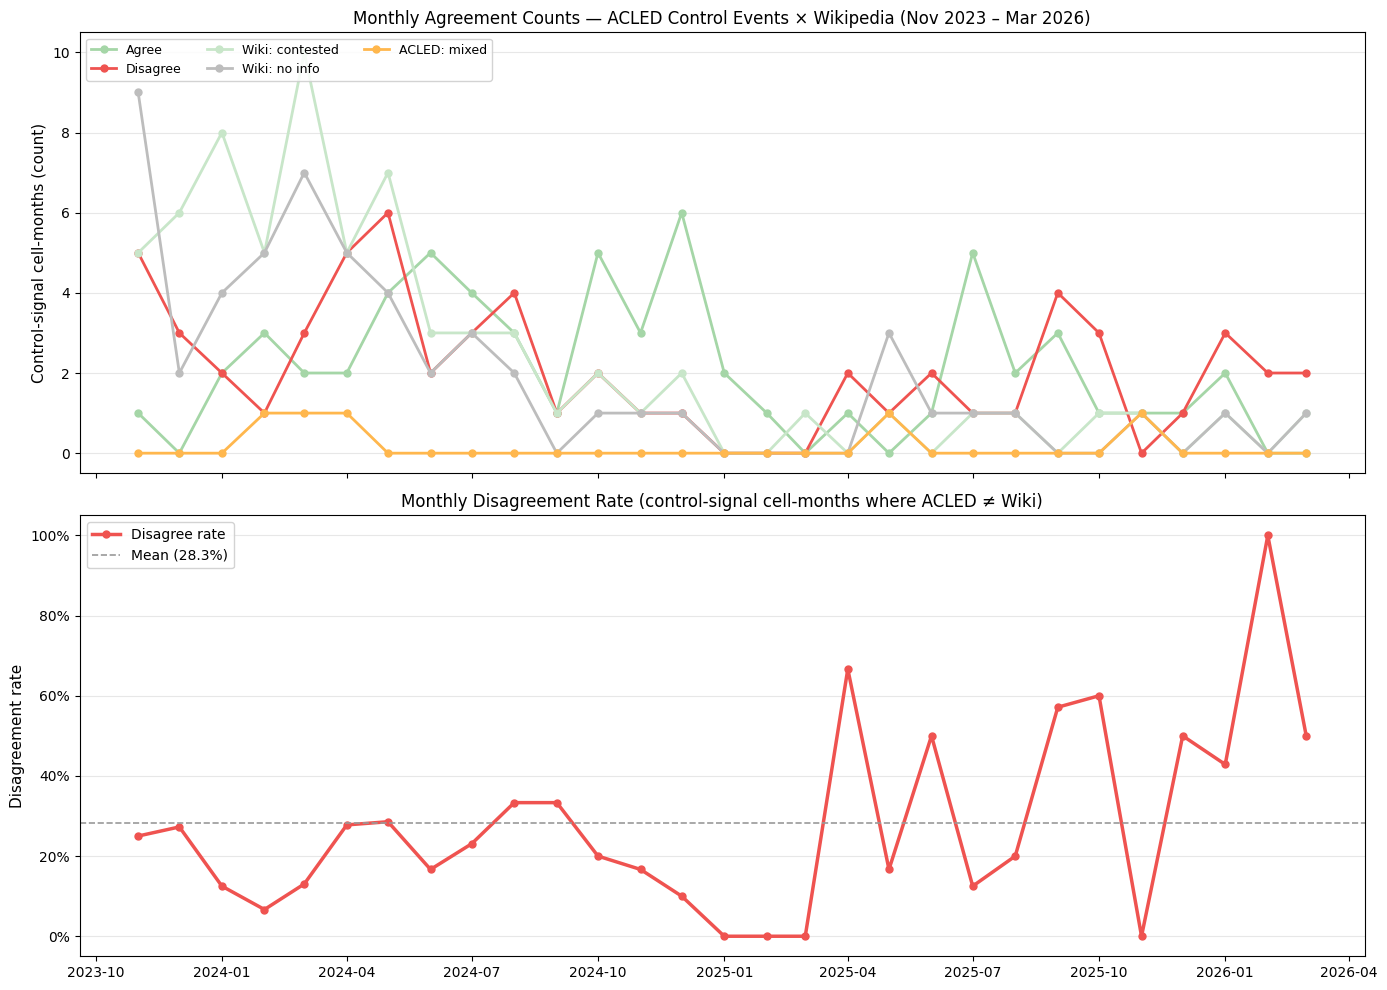

Saved: ../reports/figures/09_agreement_counts_timeseries.png


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ── Top: counts per category ─────────────────────────────────────────────────
ax = axes[0]
for col, label, color in [
    ('n_agree',     'Agree',           AGREE_COLORS['agree']),
    ('n_disagree',  'Disagree',        AGREE_COLORS['disagree']),
    ('n_contested', 'Wiki: contested', AGREE_COLORS['wiki_contested']),
    ('n_no_info',   'Wiki: no info',   AGREE_COLORS['no_info']),
    ('n_mixed',     'ACLED: mixed',    AGREE_COLORS['acled_mixed']),
]:
    ax.plot(monthly_overlap['ym_dt'], monthly_overlap[col],
            '-o', color=color, label=label, ms=5, lw=2)
ax.set_ylabel('Control-signal cell-months (count)', fontsize=11)
ax.set_title('Monthly Agreement Counts — ACLED Control Events × Wikipedia (Nov 2023 – Mar 2026)',
             fontsize=12)
ax.legend(ncol=3, fontsize=9, loc='upper left', framealpha=0.85)
ax.grid(axis='y', alpha=0.3)

# ── Bottom: disagreement rate ─────────────────────────────────────────────────
ax = axes[1]
ax.plot(monthly_overlap['ym_dt'],
        monthly_overlap['disagree_rate'] * 100,
        '-o', color=AGREE_COLORS['disagree'], ms=5, lw=2.5, label='Disagree rate')
mean_rate = monthly_overlap['disagree_rate'].mean() * 100
ax.axhline(mean_rate, ls='--', color='#999', lw=1.2, label=f'Mean ({mean_rate:.1f}%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Disagreement rate', fontsize=11)
ax.set_title('Monthly Disagreement Rate (control-signal cell-months where ACLED ≠ Wiki)',
             fontsize=12)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
FIG_TS = FIG / '09_agreement_counts_timeseries.png'
plt.savefig(FIG_TS, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_TS}')

## 10. Spatial map of disagreement clusters — save PNG

Per-cell fraction of overlap-window months where ACLED control signal and Wikipedia disagree.
Cells with persistently high disagreement may mark areas of rapid front-line change that
Wikipedia hasn't yet captured.

Cells with control signals in overlap window: 104
Cells with ≥1 disagreement:                   36

Disagree rate distribution:
count    104.000
mean       0.216
std        0.330
min        0.000
25%        0.000
50%        0.000
75%        0.500
max        1.000


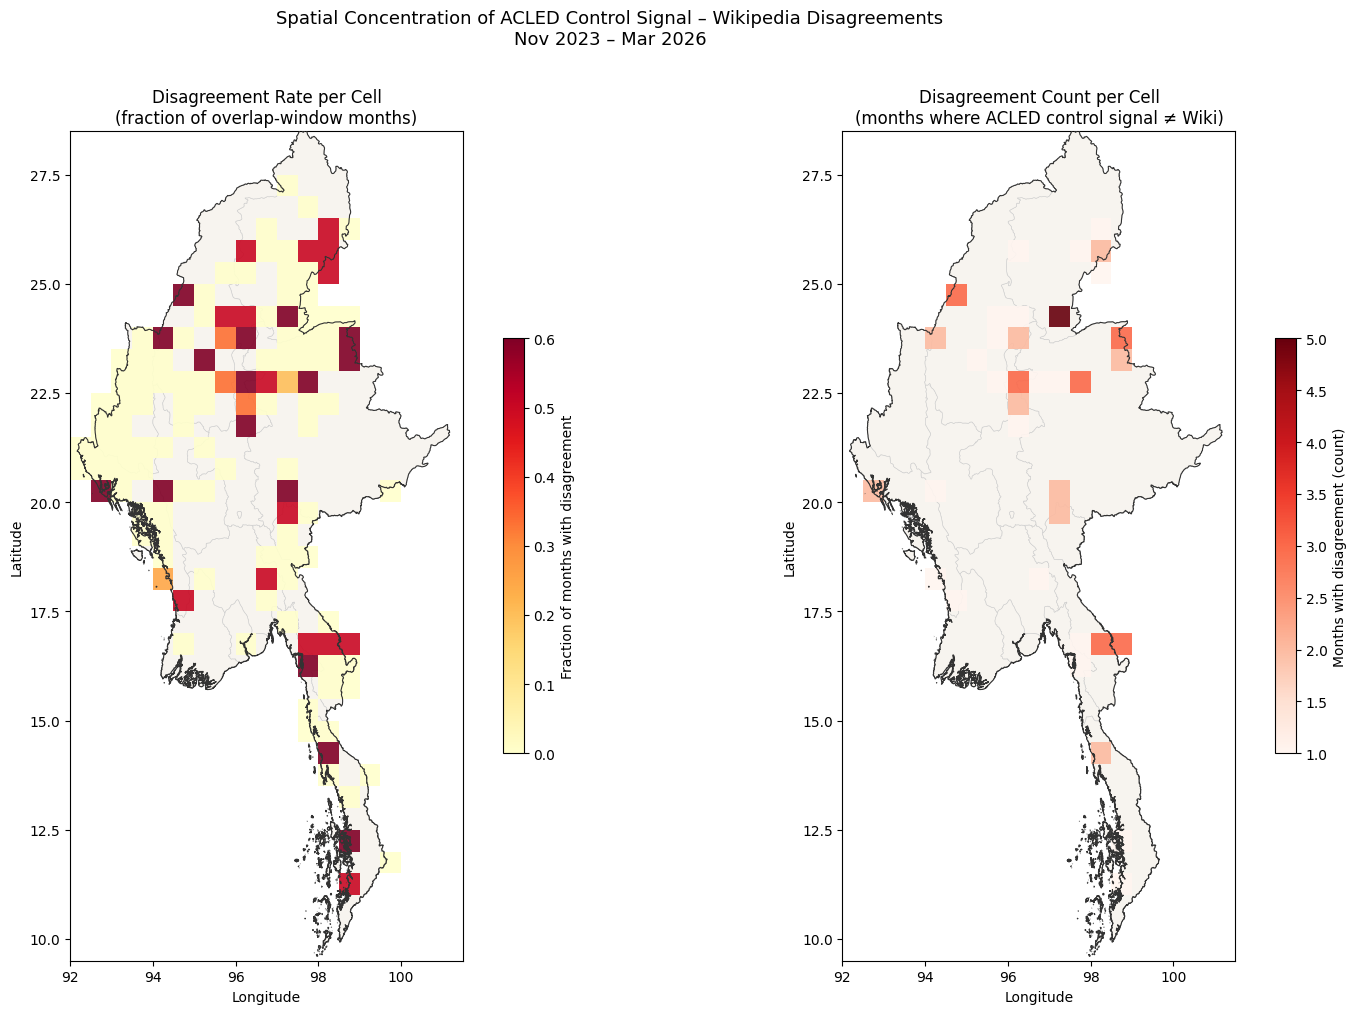

Saved: ../reports/figures/09_disagreement_cells_map.png


In [12]:
cell_stats = (
    overlap
    .groupby('priogrid_gid')
    .agg(
        n_months      = ('year_month',  'nunique'),
        n_disagree    = ('agreement',   lambda x: (x == 'disagree').sum()),
        n_agree       = ('agreement',   lambda x: (x == 'agree').sum()),
        n_contested   = ('agreement',   lambda x: (x == 'wiki_contested').sum()),
        n_mixed       = ('agreement',   lambda x: (x == 'acled_mixed').sum()),
        dominant_adm1 = ('admin1',      lambda x: x.mode().iloc[0] if len(x) else None),
    )
    .reset_index()
)
cell_stats['disagree_rate'] = (
    cell_stats['n_disagree'] / cell_stats['n_months'].clip(lower=1)
)

print(f'Cells with control signals in overlap window: {len(cell_stats)}')
print(f'Cells with ≥1 disagreement:                   {(cell_stats["n_disagree"] > 0).sum()}')
print()
print('Disagree rate distribution:')
print(cell_stats['disagree_rate'].describe().round(3).to_string())

cell_stats_gdf = cells_gdf.merge(cell_stats, on='priogrid_gid', how='left')
cell_stats_gdf['disagree_rate'] = cell_stats_gdf['disagree_rate'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, cmap, vmax, label, title in [
    (axes[0], 'disagree_rate', 'YlOrRd', 0.6,
     'Fraction of months with disagreement',
     'Disagreement Rate per Cell\n(fraction of overlap-window months)'),
    (axes[1], 'n_disagree',    'Reds',   None,
     'Months with disagreement (count)',
     'Disagreement Count per Cell\n(months where ACLED control signal ≠ Wiki)'),
]:
    gadm1.plot(ax=ax, color='#f7f4ef', edgecolor='#cccccc', linewidth=0.4, zorder=1)
    plot_kw = dict(column=col, ax=ax, cmap=cmap, edgecolor='none', alpha=0.9, zorder=2,
                   legend=True, legend_kwds={'label': label, 'shrink': 0.5})
    if vmax:
        plot_kw['vmin'] = 0
        plot_kw['vmax'] = vmax
    sub = cell_stats_gdf[cell_stats_gdf[col] > 0] if col == 'n_disagree' else cell_stats_gdf
    sub.plot(**plot_kw)
    gadm0.boundary.plot(ax=ax, color='#333', linewidth=0.8, zorder=3)
    ax.set_xlim(MMR[0], MMR[2]); ax.set_ylim(MMR[1], MMR[3])
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(title, fontsize=12)

plt.suptitle('Spatial Concentration of ACLED Control Signal – Wikipedia Disagreements\n'
             'Nov 2023 – Mar 2026', fontsize=13, y=1.01)
plt.tight_layout()
FIG_DM = FIG / '09_disagreement_cells_map.png'
plt.savefig(FIG_DM, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_DM}')

## 11. Small-multiples agreement map — save PNG

One panel per month in the Wikipedia overlap window (Nov 2023 – Mar 2026, 29 months).
Only cells that had at least one control signal event appear coloured;
the rest of the cell grid fades to near-white.

Months in overlap window: 29 (2023-11 → 2026-03)


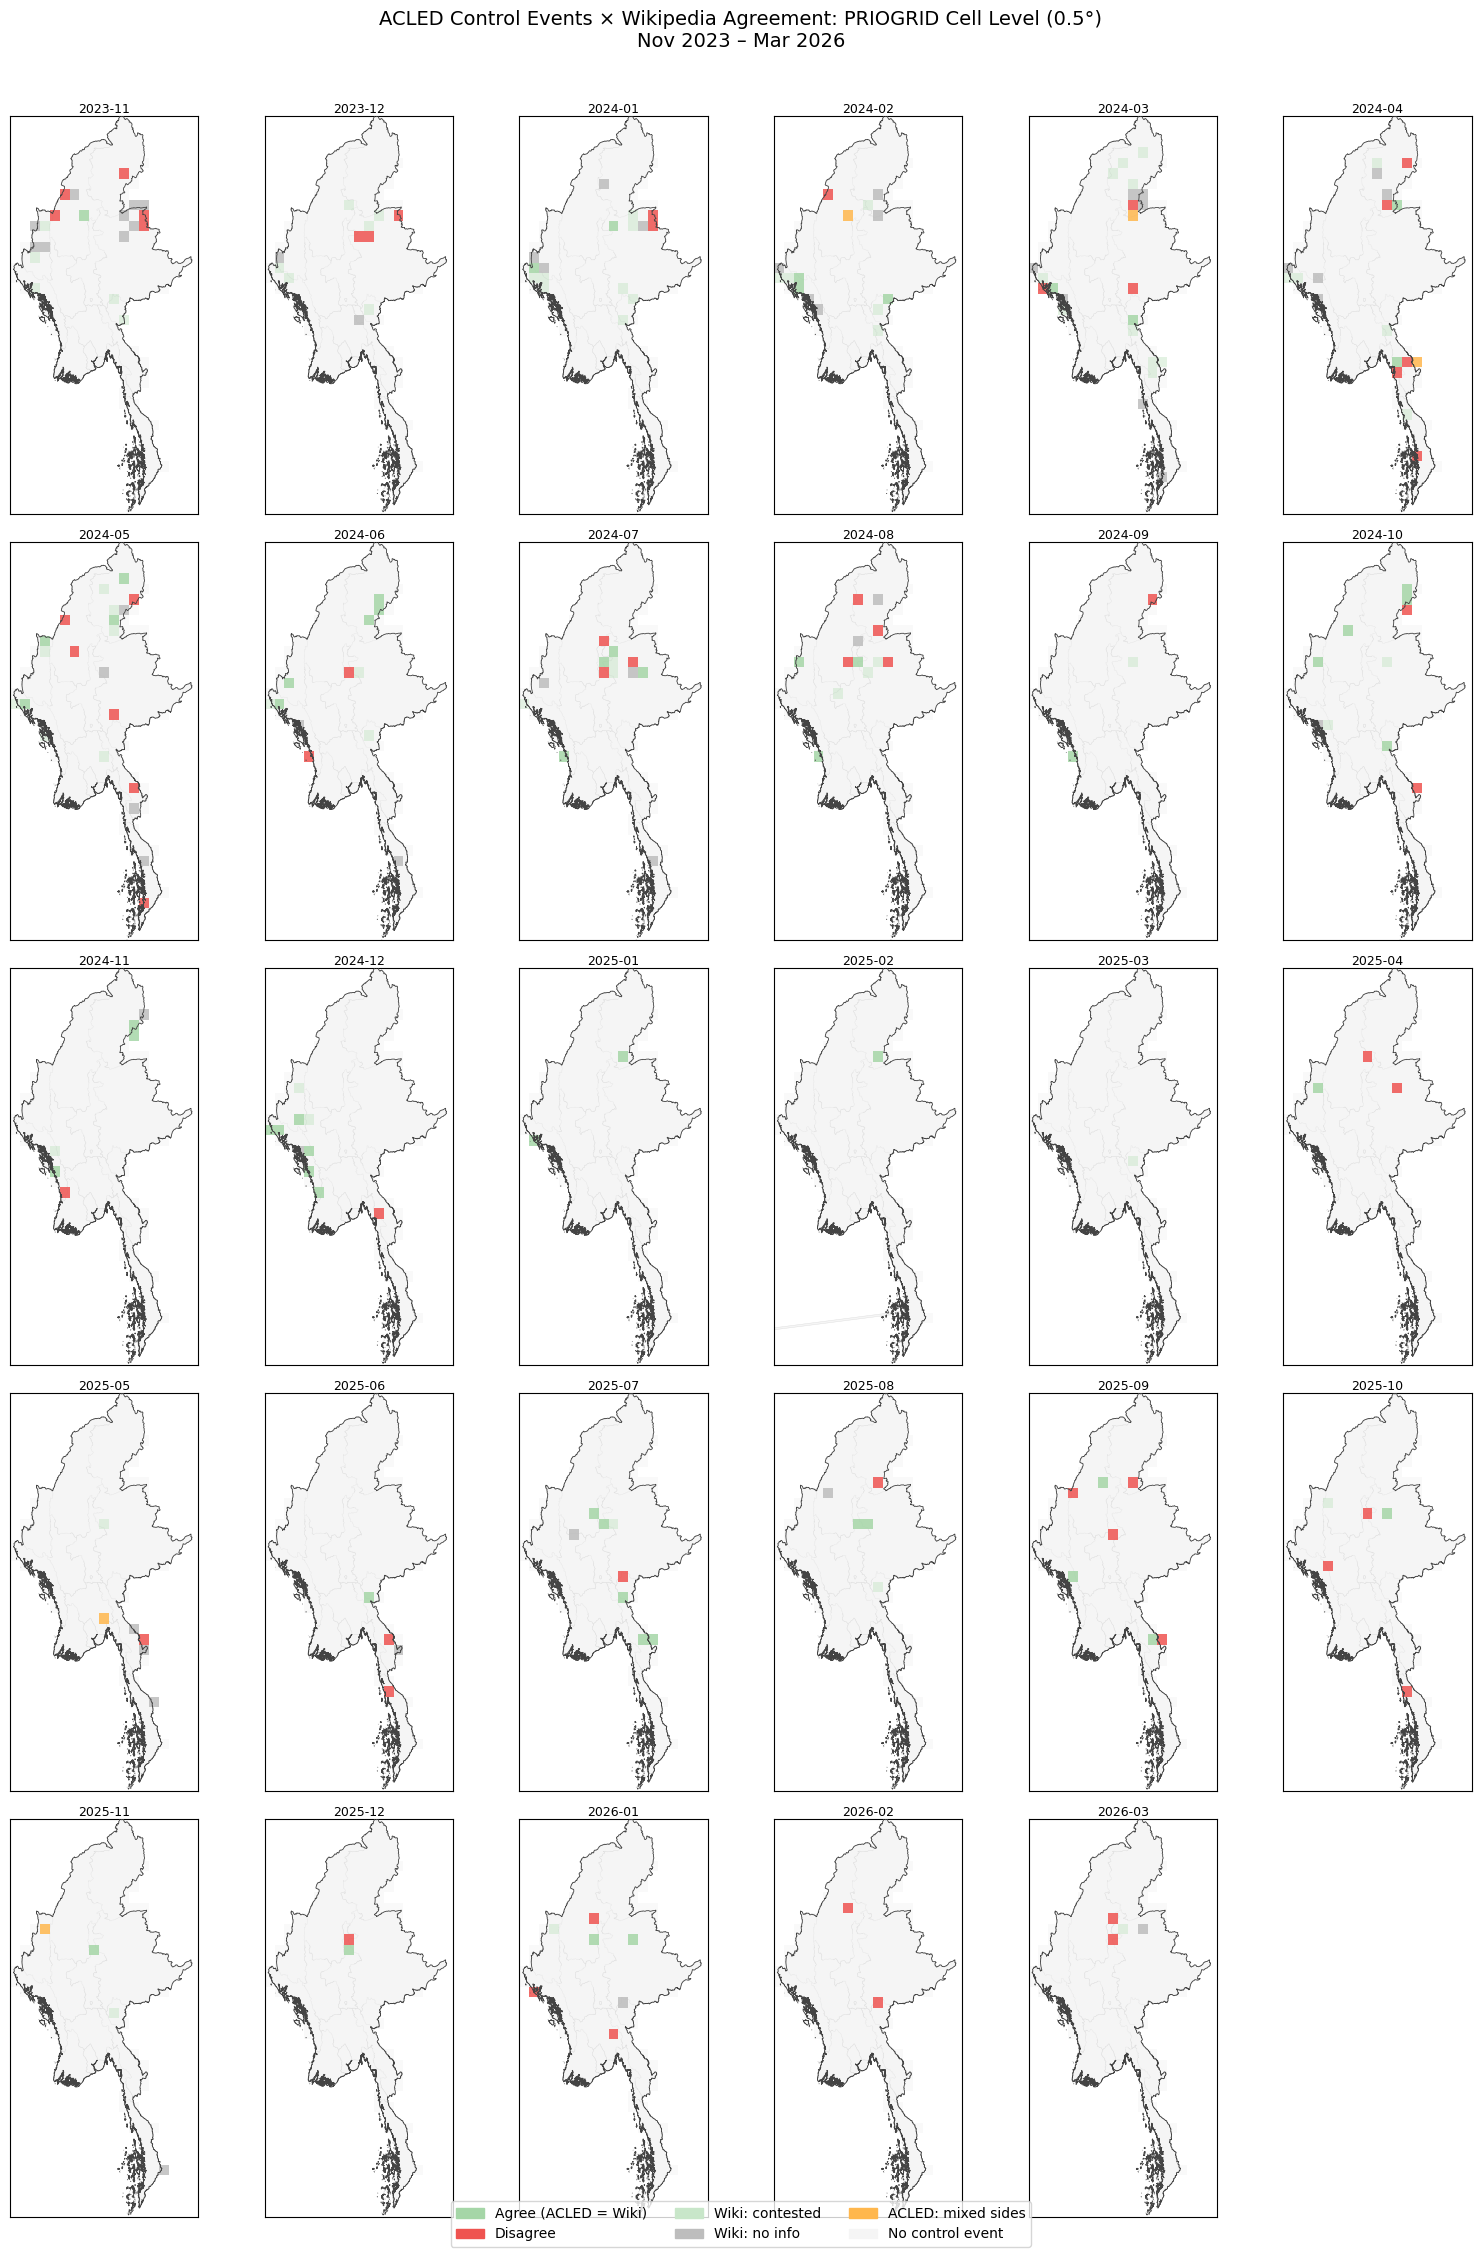

Saved: ../reports/figures/09_acled_wiki_agreement_smallmultiples.png


In [13]:
overlap_months = sorted(overlap['year_month'].unique())
print(f'Months in overlap window: {len(overlap_months)} '
      f'({overlap_months[0]} → {overlap_months[-1]})')

ncols = 6
nrows = (len(overlap_months) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 4.4))
axes_flat = axes.flatten()

for i, month in enumerate(overlap_months):
    mdata = comparison[comparison['year_month'] == month]
    plot_month_panel(axes_flat[i], mdata, month, title_fontsize=9)

for j in range(len(overlap_months), len(axes_flat)):
    axes_flat[j].set_visible(False)

legend_patches = [
    mpatches.Patch(color=AGREE_COLORS[k], label=AGREE_LABELS[k])
    for k in AGREE_ORDER
]
legend_patches.append(
    mpatches.Patch(color=AGREE_COLORS['no_acled'], label=AGREE_LABELS['no_acled'])
)
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.01), frameon=True)
fig.suptitle(
    'ACLED Control Events × Wikipedia Agreement: PRIOGRID Cell Level (0.5°)\n'
    'Nov 2023 – Mar 2026',
    fontsize=14, y=1.01
)
plt.tight_layout()
FIG_SM = FIG / '09_acled_wiki_agreement_smallmultiples.png'
plt.savefig(FIG_SM, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {FIG_SM}')

## 12. Animated GIF — one frame per month — save GIF

In [14]:
gif_frames = []
for month in overlap_months:
    fig, ax = plt.subplots(figsize=(5.5, 9))
    mdata = comparison[comparison['year_month'] == month]
    plot_month_panel(ax, mdata, '', title_fontsize=11)
    ax.set_title(f'ACLED Control Events × Wikipedia Agreement\n{month}', fontsize=12, pad=4)

    legend_patches = [
        mpatches.Patch(color=AGREE_COLORS[k], label=AGREE_LABELS[k])
        for k in AGREE_ORDER
    ]
    legend_patches.append(
        mpatches.Patch(color=AGREE_COLORS['no_acled'], label=AGREE_LABELS['no_acled'])
    )
    ax.legend(handles=legend_patches, loc='lower right', fontsize=6.5, framealpha=0.9)

    plt.tight_layout()
    buf = _io.BytesIO()
    fig.savefig(buf, format='png', dpi=80, bbox_inches='tight')
    buf.seek(0)
    gif_frames.append(Image.open(buf).convert('RGB').copy())
    plt.close(fig)
    buf.close()

GIF_PATH = FIG / '09_acled_wiki_agreement_animated.gif'
gif_frames[0].save(
    GIF_PATH, save_all=True, append_images=gif_frames[1:],
    duration=500, loop=0, optimize=True
)
print(f'Saved GIF: {GIF_PATH}')
print(f'  Frames: {len(gif_frames)}  |  Size: {GIF_PATH.stat().st_size / 1e3:.0f} KB')

Saved GIF: ../reports/figures/09_acled_wiki_agreement_animated.gif
  Frames: 29  |  Size: 349 KB


## 13. Final summary block

In [15]:
n_ov      = len(overlap)
counts    = {cat: (overlap['agreement'] == cat).sum() for cat in AGREE_ORDER}
pcts      = {cat: 100 * counts[cat] / n_ov for cat in AGREE_ORDER}

print('=' * 65)
print('FINAL SUMMARY — ACLED Control Events × Wikipedia Comparison')
print('=' * 65)
print()
print(f'Total post-coup control-signal cell-months (all):        {len(comparison):>4,}')
print(f'In Wikipedia overlap window (Nov 2023 – Mar 2026):       {n_ov:>4,}')
print()
print(f'Of {n_ov:,} cell-months with ACLED control signal events:')
print(f'  {pcts["agree"]:5.1f}%  agree with Wikipedia')
print(f'  {pcts["disagree"]:5.1f}%  disagree with Wikipedia')
print(f'  {pcts["wiki_contested"]:5.1f}%  Wikipedia: contested (partial agreement)')
print(f'  {pcts["no_info"]:5.1f}%  Wikipedia: no label for this cell-month')
print(f'  {pcts["acled_mixed"]:5.1f}%  ACLED: control signals from both sides (mixed)')
print(f'  ------')
print(f'  {sum(pcts.values()):5.1f}%  total')
print()
print('Outputs:')
for p in [
    FIG / '09_acled_wiki_agreement_smallmultiples.png',
    FIG / '09_acled_wiki_agreement_animated.gif',
    FIG / '09_agreement_counts_timeseries.png',
    FIG / '09_disagreement_cells_map.png',
    CKPT_OUT,
]:
    size = p.stat().st_size / 1e3 if p.exists() else 0
    print(f'  {p.name:<52}  {size:6.0f} KB')
print('=' * 65)

FINAL SUMMARY — ACLED Control Events × Wikipedia Comparison

Total post-coup control-signal cell-months (all):         336
In Wikipedia overlap window (Nov 2023 – Mar 2026):        251

Of 251 cell-months with ACLED control signal events:
   24.3%  agree with Wikipedia
   24.3%  disagree with Wikipedia
   27.5%  Wikipedia: contested (partial agreement)
   21.9%  Wikipedia: no label for this cell-month
    2.0%  ACLED: control signals from both sides (mixed)
  ------
  100.0%  total

Outputs:
  09_acled_wiki_agreement_smallmultiples.png               770 KB
  09_acled_wiki_agreement_animated.gif                     349 KB
  09_agreement_counts_timeseries.png                       278 KB
  09_disagreement_cells_map.png                            331 KB
  09_acled_wiki_comparison.parquet                          10 KB
